# Notebook 9: Production Drift Simulation

The orchestration layer periodically asks one question: *has the incoming patient population drifted far enough from the cohort the champion was trained on to justify a retrain?* In a live deployment that question is answered against a stream of newly-admitted encounters from the EHR.

This project has no live feed, so this notebook **manufactures that stream**. It takes the engineered feature matrix the champion trains on (`data/features.csv`) and emits a set of *newly-arrived batches*, each perturbed to mimic a real-world drift driver. Every batch is written to `data/incoming/<scenario>.csv`, schema-identical to `features.csv`, so the timer drift-check DAG (and the report below) can compare it column-for-column using **PSI** and **KS**, the two standard drift statistics, routed by column type. The untouched reference is the implicit *no-drift control*.

Generation and detection both live in `helpers/drift_sim.py`, so the **same code** runs here (authoring / visual inspection) and inside the Airflow DAG (as a PythonOperator). No duplication.

## The five scenarios (plus the no-drift control)

| Scenario | Real-world driver | Columns perturbed | Statistic |
|---|---|---|---|
| `none` | control | none | - |
| `coding_shift` | ICD-9 -> ICD-10 migration | `diag_1/2/3_cat` | PSI |
| `casemix_shift` | new referral channel / seasonal population | `age_mid`, `payer_grouped`, `admission_type/source`, `gender` | PSI |
| `los_utilization_shift` | length-of-stay / utilisation policy | `time_in_hospital`, `num_lab_procedures`, `num_medications`, `number_inpatient` | KS |
| `formulary_shift` | guideline / formulary change | `metformin`, `insulin`, `change`, `n_med_changes` | PSI |
| `mixed_severe` | EHR migration (everything moves) | all of the above | PSI + KS |

*Fidelity note:* perturbations are applied at the engineered-feature level for speed. In production the driver shifts the raw data and propagates through NB04's feature engineering. Here we simulate the resulting feature drift directly.

In [1]:
# Require the champion's training reference (run 01-05 first).
import os

_required = ["../data/features.csv"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: " + ", ".join(_missing)
        + ". Run notebooks 01 through 05 (mediwatch run) before this notebook."
    )

In [2]:
import sys
from pathlib import Path

# Make `helpers/` importable regardless of cwd (same shim as NB06).
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from helpers.constants import DRIFT_PSI_WARN, DRIFT_PSI_ALERT
from helpers.drift_sim import (
    SCENARIOS, MONITORED_COLUMNS, column_drift_report, write_scenarios,
)

REFERENCE_PATH = PROJECT_ROOT / "data" / "features.csv"
INCOMING_DIR = PROJECT_ROOT / "data" / "incoming"

reference = pd.read_csv(REFERENCE_PATH, low_memory=False)
print(f"Reference (champion training features): {reference.shape[0]:,} rows x {reference.shape[1]} cols")
print(f"Monitored columns ({len(MONITORED_COLUMNS)}): {MONITORED_COLUMNS}")
print(f"Thresholds -> WARN >= {DRIFT_PSI_WARN}, ALERT >= {DRIFT_PSI_ALERT}")

Reference (champion training features): 99,340 rows x 78 cols
Monitored columns (19): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_inpatient', 'number_emergency', 'number_diagnoses', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'admission_type', 'discharge_group', 'payer_grouped', 'race', 'gender', 'insulin', 'metformin', 'A1Cresult', 'change']
Thresholds -> WARN >= 0.1, ALERT >= 0.2


## Generate the incoming batches and compute each drift verdict

`write_scenarios()` materialises one CSV per scenario under `data/incoming/`. For each we run the **same** `column_drift_report` the DAG uses, and record the verdict that drives the retrain decision (`ALERT` -> trigger retrain).

In [3]:
written = write_scenarios(
    reference_path=str(REFERENCE_PATH),
    out_dir=str(INCOMING_DIR),
)

summary, reports = [], {}
for scenario, path in written.items():
    current = pd.read_csv(path, low_memory=False)
    report, verdict = column_drift_report(reference, current)
    reports[scenario] = report
    summary.append({
        "scenario": scenario,
        "rows": len(current),
        "verdict": verdict,
        "cols_ALERT": int((report.status == "ALERT").sum()),
        "cols_WARN": int((report.status == "WARN").sum()),
        "retrain?": "YES" if verdict == "ALERT" else "no",
        "file": os.path.relpath(path, PROJECT_ROOT),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

             scenario  rows verdict  cols_ALERT  cols_WARN retrain?                                    file
                 none 99340      OK           0          0       no                  data/incoming/none.csv
         coding_shift 99340   ALERT           3          0      YES          data/incoming/coding_shift.csv
        casemix_shift 99340   ALERT           1          0      YES         data/incoming/casemix_shift.csv
los_utilization_shift 99340   ALERT           4          0      YES data/incoming/los_utilization_shift.csv
      formulary_shift 99340   ALERT           2          0      YES       data/incoming/formulary_shift.csv
         mixed_severe 99340   ALERT          10          0      YES          data/incoming/mixed_severe.csv


In [4]:
# Per-column detail: which columns tripped, and by which statistic.
for scenario in SCENARIOS:
    fired = reports[scenario][reports[scenario].status != "OK"]
    print(f"\n=== {scenario} ===")
    print(fired.to_string(index=False) if len(fired) else "  all monitored columns within tolerance (no drift)")


=== none ===
  all monitored columns within tolerance (no drift)

=== coding_shift ===
    column method  statistic status
diag_1_cat    PSI     3.8907  ALERT
diag_2_cat    PSI     3.8906  ALERT
diag_3_cat    PSI     3.8907  ALERT

=== casemix_shift ===
       column method  statistic status
payer_grouped    PSI     0.5047  ALERT

=== los_utilization_shift ===
            column method  statistic status
  time_in_hospital    PSI     3.5399  ALERT
num_lab_procedures     KS     0.3438  ALERT
   num_medications     KS     0.2970  ALERT
  number_inpatient     KS     0.6668  ALERT

=== formulary_shift ===
   column method  statistic status
  insulin    PSI     0.3108  ALERT
metformin    PSI     0.4876  ALERT

=== mixed_severe ===
            column method  statistic status
  time_in_hospital    PSI     3.5392  ALERT
num_lab_procedures     KS     0.3429  ALERT
   num_medications     KS     0.2997  ALERT
  number_inpatient     KS     0.6668  ALERT
        diag_1_cat    PSI     3.8907  ALERT


## Does the drift actually *hurt* the champion? (measured impact)

A drift verdict says the inputs moved. It does not say the model got worse. Because every batch keeps its real `readmitted_binary` label (the perturbations touch only feature columns), we can answer the question that actually matters: **score the live champion on each drifted batch and compare to its score on the reference**, at the champion's deployed decision threshold.

Read the deltas as a pair, not as a single number. Harm shows up in two ways:

- **Misses more at-risk patients**: recall falls (for example `coding_shift`).
- **Over-flags**: recall rises but precision and F1 fall, because a sicker-looking cohort pushes more predicted probabilities above the fixed threshold (for example `los_utilization_shift` and `mixed_severe`).

Notice that `d_auc_roc` stays near zero almost everywhere: the model's *ranking* is robust to this covariate drift, but its *operating point at the fixed threshold* is not. That gap, visible in `d_f1` and `d_precision`, is exactly the harm a retrain (or a threshold recalibration) exists to repair.

In [5]:
# Champion-impact: does each scenario's drift actually hurt the live champion?
# The batches keep the real readmitted_binary label, so this is measured harm,
# not a guess. Each row is one scenario's full end-to-end story. We report the
# deltas at the champion's *deployed* decision threshold, so the table reflects
# the live operating point, not an idealised one.
from helpers.drift_sim import load_champion_scorer, build_drift_report

predict_proba_fn, threshold = load_champion_scorer(
    model_bundle_path=str(PROJECT_ROOT / "data" / "final_model.joblib"),
    pipeline_path=str(PROJECT_ROOT / "data" / "full_inference_pipeline.joblib"),
)
print(f"Champion decision threshold (deployed): {threshold:.2f}")

impact_rows = []
for scenario, path in written.items():
    current = pd.read_csv(path, low_memory=False)
    report = build_drift_report(reference, current, scenario=scenario,
                                predict_proba_fn=predict_proba_fn, threshold=threshold)
    d = report.get("champion_impact", {}).get("delta", {})
    impact_rows.append({
        "scenario": scenario,
        "verdict": report["verdict"],
        "d_recall": round(d.get("recall_pos", float("nan")), 4),
        "d_precision": round(d.get("precision_pos", float("nan")), 4),
        "d_f1": round(d.get("f1_pos", float("nan")), 4),
        "d_auc_roc": round(d.get("auc_roc", float("nan")), 4),
        "fires_retrain": "YES" if report["verdict"] == "ALERT" else "no",
    })

impact_df = pd.DataFrame(impact_rows)
print(impact_df.to_string(index=False))

Champion decision threshold (deployed): 0.53


             scenario verdict  d_recall  d_precision    d_f1  d_auc_roc fires_retrain
                 none      OK   -0.0024      -0.0003 -0.0007     0.0005            no
         coding_shift   ALERT   -0.0026       0.0013  0.0009    -0.0043           YES
        casemix_shift   ALERT   -0.0034      -0.0059 -0.0065    -0.0076           YES
los_utilization_shift   ALERT   -0.0579      -0.0061 -0.0163    -0.0178           YES
      formulary_shift   ALERT   -0.0293       0.0015 -0.0036    -0.0064           YES
         mixed_severe   ALERT   -0.0609      -0.0085 -0.0191    -0.0287           YES


## Visualising the drift

Reference (champion training) against the perturbed incoming batch, one column per statistic family. This is the picture the report turns into a PSI/KS number.

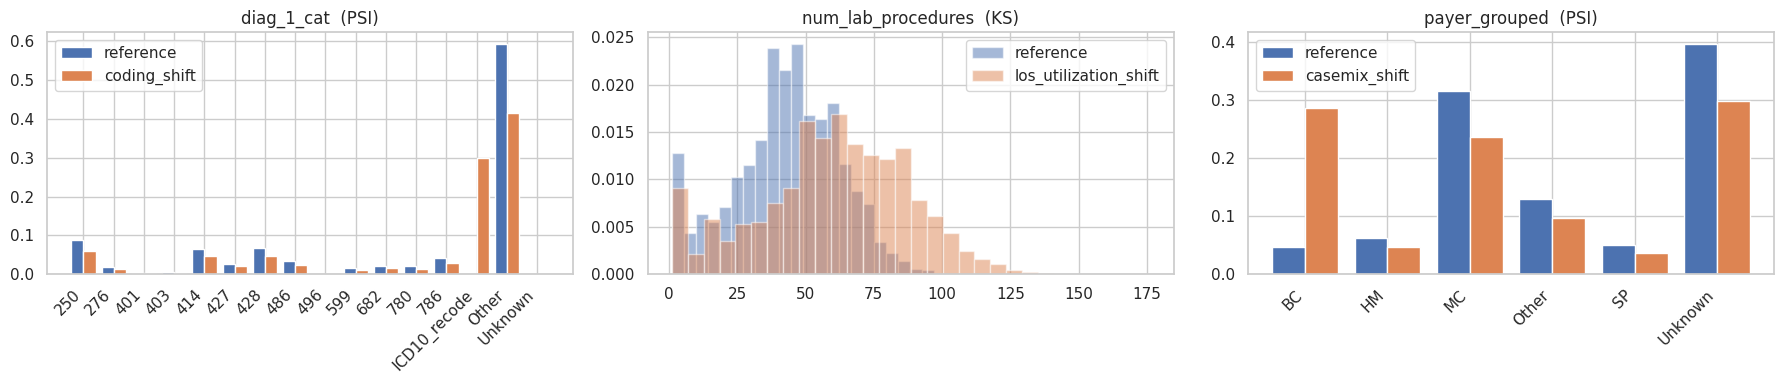

In [6]:
def _compare_categorical(ax, col, scenario):
    cur = pd.read_csv(written[scenario], low_memory=False)
    ref_p = reference[col].astype(str).value_counts(normalize=True)
    cur_p = cur[col].astype(str).value_counts(normalize=True)
    cats = ref_p.index.union(cur_p.index)
    x = np.arange(len(cats)); w = 0.4
    ax.bar(x - w / 2, ref_p.reindex(cats, fill_value=0), w, label="reference")
    ax.bar(x + w / 2, cur_p.reindex(cats, fill_value=0), w, label=scenario)
    ax.set_xticks(x); ax.set_xticklabels(cats, rotation=45, ha="right")
    ax.set_title(f"{col}  (PSI)"); ax.legend()

def _compare_numeric(ax, col, scenario):
    cur = pd.read_csv(written[scenario], low_memory=False)
    ax.hist(reference[col].dropna(), bins=30, alpha=0.5, density=True, label="reference")
    ax.hist(cur[col].dropna(), bins=30, alpha=0.5, density=True, label=scenario)
    ax.set_title(f"{col}  (KS)"); ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
_compare_categorical(axes[0], "diag_1_cat", "coding_shift")
_compare_numeric(axes[1], "num_lab_procedures", "los_utilization_shift")
_compare_categorical(axes[2], "payer_grouped", "casemix_shift")
plt.tight_layout(); plt.show()

## From detection to retraining, and what production would do

Each scenario above is a **separate end-to-end unit**: a labeled batch in `data/incoming/<scenario>.csv`, a drift verdict, a measured champion-impact delta, and (on `ALERT`) a triggered `retrain_on_drift` run **tagged with the scenario**. The orchestration is wired end to end:

1. **`scheduled_drift_check`** takes a `scenario` run-param, reads `data/incoming/<scenario>.csv`, computes the same `column_drift_report` used above plus the champion-impact block, writes `data/drift_reports/<scenario>.json`, logs it to the `medi-watch-drift-reports` MLflow experiment (tagged `drift_scenario`), and on `ALERT` triggers `retrain_on_drift` with the scenario in its conf.
2. **`retrain_on_drift`** runs HPO -> train -> conclusion -> champion gate, and tags the newly registered model version with `drift_scenario` so every retrain is attributable to the drift that caused it.
3. **`drift_scenarios_demo`** fires `scheduled_drift_check` once per scenario, so all five appear as five distinct runs in the Airflow UI in a single click. The `none` control stays `OK` and skips, which is the negative path.

**Production faithfulness.** Drift detection is the *trigger*, and in the wild it is unlabeled. The training set is the latest *labeled* production window, which only matures after outcomes are observed (for 30-day readmission, roughly 30+ days of label lag). Here the drifted batch is genuinely labeled because the simulation perturbs a labeled historical frame, so the impact delta is real, but the perturbation shifts features without re-deriving outcomes, so it models **covariate drift with stable labels** rather than full concept drift. `retrain_on_drift` therefore retrains on the labeled `train_test` window as a stand-in for "the latest matured labeled window", justified by the measured operating-point degradation (the `d_f1` / `d_precision` erosion) above. Because the AUC barely moves while the fixed-threshold operating point shifts, a performance-driven verdict (retrain or recalibrate on measured harm rather than PSI/KS alone) is the natural next enhancement.

In [7]:
# Optionally launch the five scheduled_drift_check runs straight from the
# notebook via the Airflow REST API. Set AIRFLOW_API_URL / AIRFLOW_API_USER /
# AIRFLOW_API_PASSWORD to enable, otherwise this prints how to trigger manually.
import os
import requests

api_url = os.environ.get("AIRFLOW_API_URL")  # e.g. http://localhost:18080/api/v2
user = os.environ.get("AIRFLOW_API_USER", "airflow")
password = os.environ.get("AIRFLOW_API_PASSWORD", "airflow")

scenarios = [s for s in SCENARIOS if s != "none"]  # the five drift scenarios
if not api_url:
    print("AIRFLOW_API_URL not set - trigger from the Airflow UI instead:")
    print("  - run the 'drift_scenarios_demo' DAG (fires all five at once), or")
    print("  - trigger 'scheduled_drift_check' with conf {\"scenario\": \"<name>\"}")
    print(f"  scenarios: {scenarios}")
else:
    for scenario in scenarios:
        resp = requests.post(
            f"{api_url}/dags/scheduled_drift_check/dagRuns",
            auth=(user, password),
            json={"conf": {"scenario": scenario}},
            timeout=30,
        )
        print(f"  {scenario}: HTTP {resp.status_code}")

AIRFLOW_API_URL not set - trigger from the Airflow UI instead:
  - run the 'drift_scenarios_demo' DAG (fires all five at once), or
  - trigger 'scheduled_drift_check' with conf {"scenario": "<name>"}
  scenarios: ['coding_shift', 'casemix_shift', 'los_utilization_shift', 'formulary_shift', 'mixed_severe']
